In [34]:
# K Means Clustering Algorithm

# Sample dataset
import pandas as pd
dataset = pd.DataFrame({
    'Colour': ['Red', 'Green', 'Blue', 'Green', 'Red', 'Blue', 'Red', 'Green', 'Blue', 'Red'],
    'Size': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'Price': [10, 20, 30, 50, 60, 70, 80, 90, 100, 110],
    'Qty': [100, 250, 300, 150, 120, 220, 330, 440, 550, 660]
})
dataset.head()

,Colour,Size,Price,Qty
0,Red,1,10,100
1,Green,2,20,250
2,Blue,3,30,300
3,Green,4,50,150
4,Red,5,60,120


In [43]:
# Converting the colour column to numerical values using one hot encoding
dataset2 = pd.get_dummies(dataset[['Colour', 'Size', 'Price','Qty']], drop_first=True)
dataset2.head()

,Size,Price,Qty,Colour_Green,Colour_Red
0,1,10,100,False,True
1,2,20,250,True,False
2,3,30,300,False,False
3,4,50,150,True,False
4,5,60,120,False,True


In [46]:
# Scaling the data using StandardScaler
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
dataset2 = scaler.fit_transform(dataset2)
dataset2[:8]


array([[-1.5666989 , -1.60018938, -1.19456053, -0.65465367,  1.22474487],
       [-1.21854359, -1.29246066, -0.34935261,  1.52752523, -0.81649658],
       [-0.87038828, -0.98473193, -0.06761663, -0.65465367, -0.81649658],
       [-0.52223297, -0.36927447, -0.91282455,  1.52752523, -0.81649658],
       [-0.17407766, -0.06154575, -1.08186614, -0.65465367,  1.22474487],
       [ 0.17407766,  0.24618298, -0.51839419, -0.65465367, -0.81649658],
       [ 0.52223297,  0.55391171,  0.10142495, -0.65465367,  1.22474487],
       [ 0.87038828,  0.86164044,  0.72124409,  1.52752523, -0.81649658]])

In [47]:
# Applying K means clustering algorithm to the dataset
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=2, random_state=0, max_iter=15)
kmeans.fit(dataset2)
print(kmeans.labels_)  # the labels assigned to each data point by the K Means Clustering algorithm. The labels are integers that represent the cluster to which each data point belongs. In this case, we have 2 clusters, so the labels will be either 0 or 1.
print(kmeans.cluster_centers_)  # the coordinates of the cluster centers. Each row in the output corresponds to a cluster center, and each column corresponds to a feature in the dataset. The values in the output represent the mean value of each feature for the data points that belong to that cluster. For example, if we have 2 clusters and 4 features, the output will be a 2x4 array where each row represents a cluster center and each column represents a feature.
print(kmeans.inertia_)  # inertia is the sum of squared distances of samples to their closest cluster center. The lower the inertia, the better the model fits the data. We can use this value to compare different models and choose the one with the lowest inertia.
print(kmeans.n_iter_)  # the algorithm converged in 2 iterations, which means that it found the optimal cluster centers in 2 iterations. If we had set max_iter to a higher value, the algorithm would have continued to iterate until it converged or reached the maximum number of iterations.


[0 0 0 0 0 0 0 1 1 1]
[[-0.52223297 -0.50115821 -0.57474139 -0.03117398  0.05832118]
 [ 1.21854359  1.16936916  1.34106323  0.0727393  -0.13608276]]
29.966287794356667
2


c:\Users\prern\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [50]:
# getting the original dataset back with the cluster labels
# First, convert dataset2 (numpy array) back to a DataFrame with appropriate column names
columns = ['Size', 'Price', 'Qty', 'Colour_Green', 'Colour_Red']
dataset3 = pd.DataFrame(dataset2, columns=columns)

dataset3['Cluster'] = kmeans.labels_
dataset3.head(10)

,Size,Price,Qty,Colour_Green,Colour_Red,Cluster
0,-1.566699,-1.600189,-1.194561,-0.654654,1.224745,0
1,-1.218544,-1.292461,-0.349353,1.527525,-0.816497,0
2,-0.870388,-0.984732,-0.067617,-0.654654,-0.816497,0
3,-0.522233,-0.369274,-0.912825,1.527525,-0.816497,0
4,-0.174078,-0.061546,-1.081866,-0.654654,1.224745,0
5,0.174078,0.246183,-0.518394,-0.654654,-0.816497,0
6,0.522233,0.553912,0.101425,-0.654654,1.224745,0
7,0.870388,0.861640,0.721244,1.527525,-0.816497,1
8,1.218544,1.169369,1.341063,-0.654654,-0.816497,1
9,1.566699,1.477098,1.960882,-0.654654,1.224745,1


In [52]:
# Visualizing the clusters with qty and price    
import matplotlib.pyplot as plt
plt.scatter(dataset2['Price'], dataset2['Qty'], c=kmeans.labels_)
plt.xlabel('Price')
plt.ylabel('Qty')
plt.title('K Means Clustering')
plt.show()

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

In [17]:
# checking accuracy of the model
kmeans.inertia_  # inertia is the sum of squared distances of samples to their closest cluster center. The lower the inertia, the better the model fits the data. We can use this value to compare different models and choose the one with the lowest inertia.

3977.666666666667

c:\Users\prern\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\prern\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\prern\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\prern\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

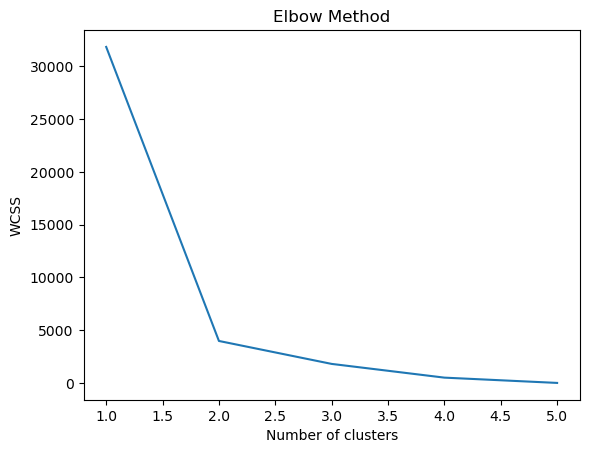

In [19]:
# WCSS (Within Cluster Sum of Squares) is the sum of squared distances of samples to their closest cluster center. The lower the WCSS, the better the model fits the data. We can use this value to compare different models and choose the one with the lowest WCSS.
wcss = []
for i in range(1, len(dataset2) + 1):
    kmeans = KMeans(n_clusters=i, random_state=0)
    kmeans.fit(dataset2)
    wcss.append(kmeans.inertia_)
plt.plot(range(1, len(dataset2) + 1), wcss)
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

In [ ]:
# looking at the WCSS plot, we can see that the elbow point is at 2 clusters, which is the optimal number of clusters for this dataset. Therefore, we can conclude that the K Means Clustering algorithm has successfully clustered the data into 2 clusters.

In [42]:
# checking the Silhouette Score for the model
''' Silhoutte score stays between -1 and 1
0.71 – 1.0: Strong Structure. A very strong, well-defined cluster structure has been found.
0.51 – 0.70: Reasonable Structure. Good, clear clusters are present.
0.26 – 0.50: Weak Structure. The structure is artificial or weak; it may be worth checking if a different number of clusters or algorithm is better.
0.25: No Substantial Structure. The data does not clearly belong in these clusters.
0: Poor Clustering. The data points are likely assigned to the wrong
'''
from sklearn.metrics import silhouette_score
silhouette_score(dataset2, kmeans.labels_)  # the silhouette score is a measure of how well each data point fits into its assigned cluster. The silhouette score ranges from -1 to 1, where a score of 1 indicates that the data point is well matched to its own cluster and poorly matched to neighboring clusters, while a score of -1 indicates that the data point is poorly matched to its own cluster and well matched to neighboring clusters. A score of 0 indicates that the data point is on or very close to the decision boundary between two neighboring clusters. In general, a higher silhouette score indicates a better clustering solution.


0.6021988653210593

In [31]:
# Itererations of K Means Clustering Algorithm
# how many iterations does the K Means Clustering algorithm take to converge? We can check this by looking at the n_iter_ attribute of the KMeans object after fitting the model. This attribute gives us the number of iterations it took for the algorithm to converge.
kmeans = KMeans(n_clusters=2, random_state=0, max_iter=10)
kmeans.fit(dataset2)
print(kmeans.n_iter_)  # the algorithm converged in 2 iterations, which means that it found the optimal cluster centers in 2 iterations. If we had set max_iter to a higher value, the algorithm would have continued to iterate until it converged or reached the maximum number of iterations.
print(kmeans.inertia_)  # inertia is the sum of squared distances of samples to their closest cluster center. The lower the inertia, the better the model fits the data. We can use this value to compare different models and choose the one with the lowest inertia.

3
76605.90476190476


c:\Users\prern\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [38]:
dataset3 = dataset2.copy()

In [39]:
# predicting the cluster for current data points
print(kmeans.predict(dataset2))  # the predicted cluster labels for each data point in the dataset. The output will be an array of integers where each integer represents the cluster to which the corresponding data point belongs. In this case, since we have 2 clusters, the output will be an array of 0s and 1s, where 0 represents one cluster and 1 represents the other cluster.

# adding the cluster labels to the original dataset
dataset3['Cluster'] = kmeans.labels_
dataset3.head(10)

[0 0 0 0 0 0 0 1 1 1]


,Size,Price,Qty,Colour_Green,Colour_Red,Cluster
0,1,10,100,False,True,0
1,2,20,250,True,False,0
2,3,30,300,False,False,0
3,4,50,150,True,False,0
4,5,60,120,False,True,0
5,6,70,220,False,False,0
6,7,80,330,False,True,0
7,8,90,440,True,False,1
8,9,100,550,False,False,1
9,10,110,660,False,True,1


In [ ]:
# Visualizing the clusters with colour
plt.scatter(dataset2['Size'], dataset2['Price'], c=kmeans.labels_) 
plt.xlabel('Size')
plt.ylabel('Price')
plt.title('K Means Clustering')
plt.show()